In [1]:
import logomaker
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
import glob
results_file = glob.glob('/clusterfs/nilah/sergio/RFdifussion/7RTD/*/*.csv')
print(len(results_file))

955


In [3]:
import pandas as pd
import os

def aggregate_results(results_files, run_id_level=-2, extra_columns=None):
    """
    Aggregate CSV files into a single DataFrame with run identifiers.
    
    Args:
        results_files (list): List of paths to CSV files.
        run_id_level (int): Directory level to extract run ID (e.g., -2 for parent of filename).
        extra_columns (dict): Optional dictionary of column_name: lambda_function to add metadata.
    
    Returns:
        pd.DataFrame: Concatenated DataFrame with run IDs and optional columns.
    """
    if not results_files:
        print("Warning: No files provided.")
        return pd.DataFrame()

    dfs = []
    for file_path in results_files:
        # try:
        # Read CSV
        tmp = pd.read_csv(file_path)
        
        # Extract run ID from path
        run_id = os.path.split(os.path.dirname(file_path))[run_id_level]
        tmp['RUN'] = run_id
        
        # Add optional columns
        # if extra_columns:
        #     for col_name, func in extra_columns.items():
        #         tmp[col_name] = func(file_path)
        
        dfs.append(tmp)
        # print(f"Processed: {file_path}")

    # Concatenate all DataFrames
    if dfs:
        results = pd.concat(dfs, axis=0 )# , ignore_index=True)
        print(f"Aggregated {len(dfs)} files into DataFrame with {len(results)} rows.")
        return results
    else:
        print("No valid files processed.")
        return pd.DataFrame()

# Example usage for RFdiffusion results
# results_dir = "/clusterfs/nilah/sergio/RFdifussion/outputs/EPITOPE_SERIES_20250416/*/af2.csv"
results_files = glob.glob('/clusterfs/nilah/sergio/RFdifussion/7RTD/*/*.csv')

# # Define extra columns (e.g., extract contigs, iterations, num_seqs from run name)
# extra_columns = {
#     'contigs': lambda x: x.split('/')[-3].split('_C')[1].split('_I')[0],
#     'iterations': lambda x: x.split('_I')[1].split('_NS')[0],
#     'num_seqs': lambda x: x.split('_NS')[1].split('_')[0]
# }

# Aggregate results
results = aggregate_results(results_files, run_id_level=-2) #, extra_columns=extra_columns)

Aggregated 955 files into DataFrame with 30560 rows.


array([[<Axes: title={'center': 'i_ptm'}>]], dtype=object)

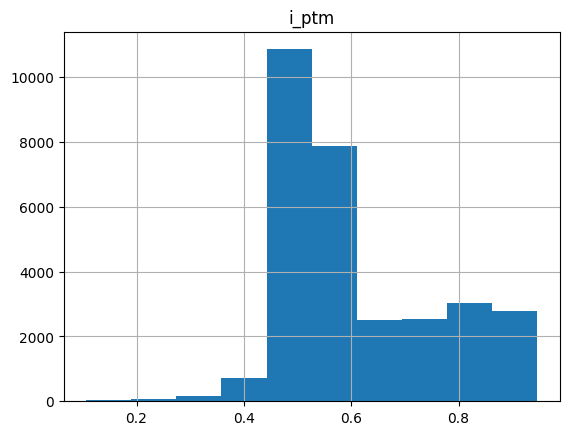

In [4]:
results.hist('i_ptm')

array([[<Axes: title={'center': 'i_pae'}>]], dtype=object)

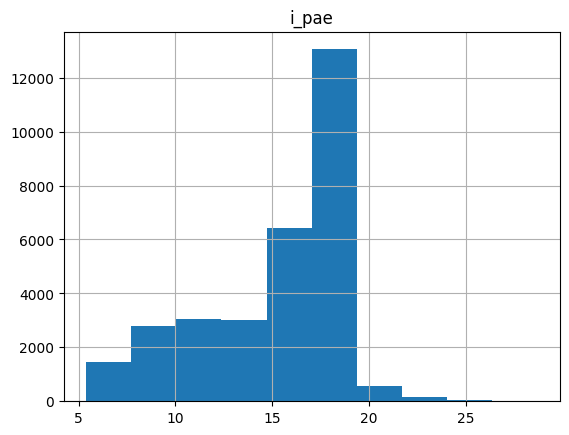

In [5]:
results.hist('i_pae')

In [6]:
# # Filter top sequences by structural confidence
# filtered = results[
#     (results['plddt'] > 0.8) &
#     (results['ptm'] > 0.05) &
#     (results['pae'] < 5.0) &
#     (results['rmsd'] < 2.0)
# ].sort_values(by='plddt', ascending=False)

# print(filtered[['seq', 'plddt', 'ptm', 'pae', 'rmsd', 'mpnn']].head(10))


In [7]:
results['epitope'] = results['seq'].apply(lambda x: x.split("/")[1])
results['length'] = results['epitope'].apply(lambda x: len(x))

In [8]:
results.sort_values(by='plddt', ascending=False)

,Unnamed: 0,design,n,mpnn,plddt,i_ptm,i_pae,rmsd,seq,RUN,epitope,length
0,0,0,0,1.339388,0.922469,0.939850,5.715950,14.813799,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/7RTD,SQAPVVAI,8
2,2,0,2,1.330234,0.922469,0.939850,5.715950,14.813799,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/7RTD,SQAPVVAI,8
9,9,0,9,1.332616,0.922469,0.939850,5.715950,14.813799,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/7RTD,SQAPVVAI,8
26,26,0,26,1.295440,0.922469,0.939850,5.715950,14.813799,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/7RTD,SQAPVVAI,8
18,18,0,18,0.697885,0.918757,0.946168,5.704641,0.819085,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/7RTD,SSLPPVIPAA,10
...,...,...,...,...,...,...,...,...,...,...,...,...
29,29,0,29,1.252044,0.147783,0.153149,25.900809,15.124124,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/7RTD,SRELTVVE,8
17,17,0,17,1.179920,0.147783,0.153149,25.900809,15.124124,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/7RTD,SRELTVVE,8
2,2,0,2,1.213150,0.147783,0.153149,25.900809,15.124124,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/7RTD,SRELTVVE,8
30,30,0,30,1.252247,0.147783,0.153149,25.900809,15.124124,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/7RTD,SRELTVVE,8


In [9]:
results = results.drop_duplicates('epitope')

In [10]:
import seaborn as sns

<Axes: xlabel='length', ylabel='plddt'>

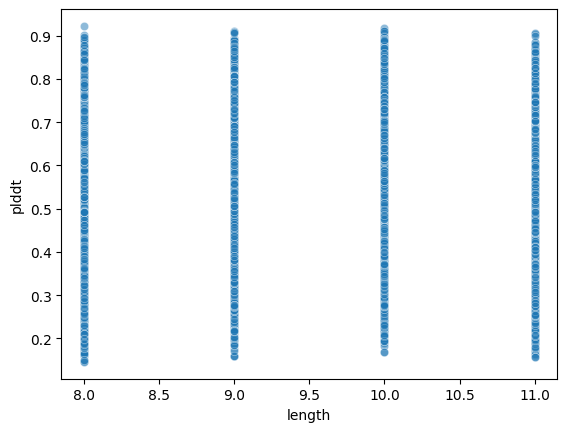

In [11]:
sns.scatterplot(data=results, x='length', y='plddt', alpha=0.5)

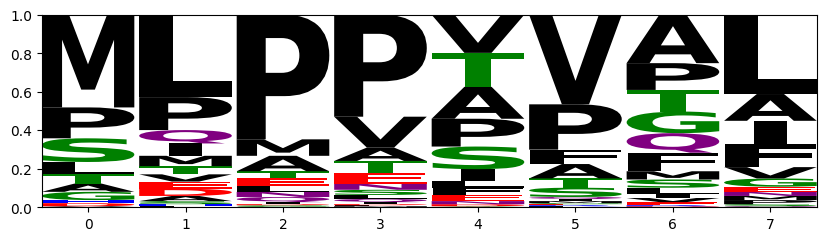

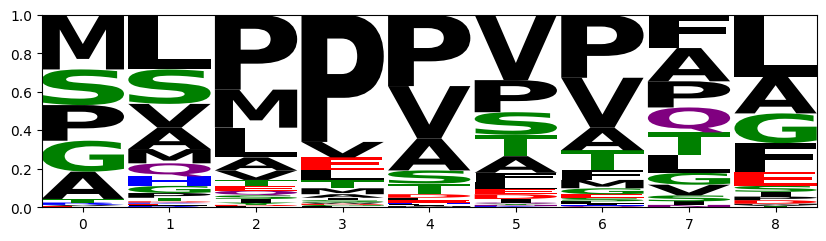

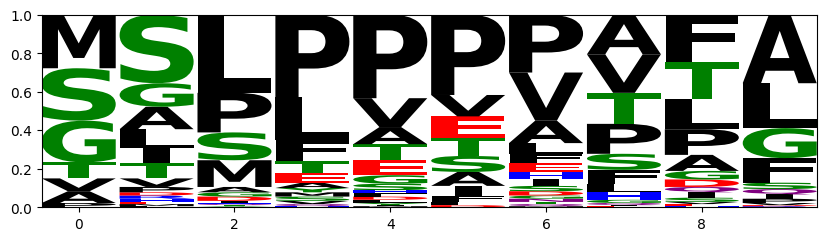

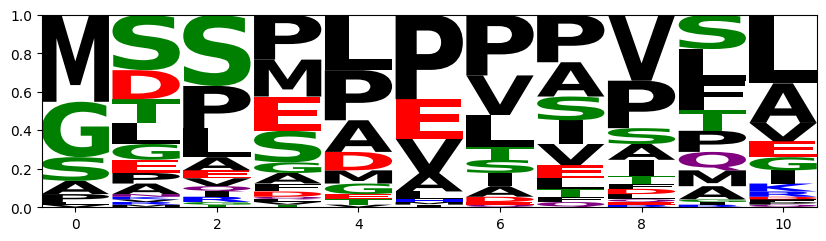

In [12]:
for n in range(8, 12):

    seq_length = n

    sequences = results[(results['epitope'].str.len() == seq_length) & (results['plddt'] > 0.8)]['epitope'].tolist()

    # Create a list of amino acids (standard 20 amino acids)
    amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

    freq_matrix = np.zeros((seq_length, len(amino_acids)))

    # Populate the frequency matrix: count occurrences of each amino acid at each position
    for seq in sequences:
        for i, aa in enumerate(seq):
            aa_index = amino_acids.index(aa)
            freq_matrix[i, aa_index] += 1

    # Normalize the frequency matrix to get probabilities (frequencies sum to 1 at each position)
    freq_matrix = freq_matrix / len(sequences)

    # Create a DataFrame for logomaker
    freq_df = pd.DataFrame(freq_matrix, columns=amino_acids)

    # Generate the sequence logo
    logo = logomaker.Logo(freq_df, color_scheme='chemistry') #, font_name='Arial Rounded MT Bold')


In [13]:
results = results.iloc[:, 1:]

In [14]:
results.to_csv('./HLAA0201_PDB_7RTD_RFdiffusion_sequences.csv', index=False)

Name | What it captures | Threshold (after ≤ 5 Å cutoff) | hotspot = "…", ready to copy
core_hotspot | Only the strongest binding hot‑spots—absolute core you almost never want to mutate. |  ≥ 4 distinct protein contacts | "A66,A70,A159"
high_contact | Core + secondary hubs. Good default when you want to preserve the bulk of the binding energy. |  ≥ 3 contacts | "A66,A70,A73,A77,A97,A147,A159"
medium_contact | Moderately important residues; nice to keep fixed if you want a very native‑like interface. |  = 2 contacts | "A7,A63,A99,A116,A143,A146,A155,A156"
low_contact | Peripheral/edge residues; usually safe to let RFdiffusion mutate for better packing/solubility. |  = 1 contact | "A5,A9,A33,A45,A59,A67,A69,A76,A80,A81,A84,A95,A114,A123,A124,A142,A152,A160,A163,A167,A171"
combo_high_low | Lock the high‑energy core while leaving medium residues flexible (high + low combined). | see above | "A5,A9,A33,A45,A59,A66,A67,A69,A70,A73,A76,A77,A80,A81,A84,A95,A97,A114,A123,A124,A142,A147,A152,A159"
all_contacts | Every chain‑A residue that has ≥ 1 heavy‑atom within 5 Å of chain C (36 total). Use to freeze the entire native interface. |  ≥ 1 contact | "A5,A7,A9,A33,A45,A59,A63,A66,A67,A69,A70,A73,A76,A77,A80,A81,A84,A95,A97,A99,A114,A116,A123,A124,A142,A143,A146,A147,A152,A155,A156,A159,A160,A163,A167,A171"
user_hotspot | Your original 9‑residue list. | (user‑defined) | "A7,A9,A59,A63,A66,A70,A99,A159,A167"

In [15]:
import glob
import os
import pandas as pd

# Base directory
base_dir = '/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK'

# List all files and filter for CSV and XLS
all_files = glob.glob(os.path.join(base_dir, '*'))
data_files = [f for f in all_files if f.lower().endswith(('.csv', '.xls'))]

# Display the list of data files
for f in data_files:
    print(f)

# Read each file into a DataFrame
dfs = {}
for f in data_files:
    name = os.path.basename(f)
    if f.lower().endswith('.csv'):
        dfs[name] = pd.read_csv(f)
    else:  # .xls tab-delimited
        dfs[name] = pd.read_csv(f, sep='\t', header=1)

print("\nLoaded DataFrames:")
for name, df in dfs.items():
    print(f"{name}: {df.shape} rows, {df.shape[1]} columns")


/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/lowbinders_A0201_netmhc.xls
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/evaluation_A0201HLA-lowbinders_mhcflurry_unique.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/evaluation_A0201epitope-highbinders_mhcflurry_unique.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/highbinders_A0201_netmhc.xls
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/A0201highbinders_mhc_flurry.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/A0201lowbinders_mhc_flurry.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/evaluation_A0201epitope-lowbinders_mhcflurry_unique.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/evaluation_A0201HLA-highbinders_mhcflurry_unique.csv

Loaded DataFrames:
lowbinders_A0201_netmhc.xls: (309, 11) rows, 11 columns
evaluation_A0201HLA-lowbinders_mhcflurry_unique.csv: (71, 2) rows, 2 columns
evaluation_A0201epitope-highbinders_mhcflurry

In [16]:
HLA_athena = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/performances/predictions_20250423.204321.tsv', sep = '\t')
HLA_athena

,pep,len,model_A0201,MSi_A0201,prank.MSi_A0201,best.MSi,best.MSi_allele,assign.MSi_scores,assign.MSi_allele
0,GMLPAPPL,8,panpan,0.775238,1.557303,0.775238,A0201,0.775238,A0201
1,VRESPEVT,8,panpan,0.008188,32.050964,0.008188,A0201,NaN,unknown
2,PTMTPAPP,8,panpan,0.010776,29.219358,0.010776,A0201,NaN,unknown
3,PVSLPAPP,8,panpan,0.053162,15.628531,0.053162,A0201,NaN,unknown
4,SSLIVVPG,8,panpan,0.058255,14.988930,0.058255,A0201,NaN,unknown
...,...,...,...,...,...,...,...,...,...
449,MEVEVHLEEV,10,specific,0.072925,8.994611,0.072925,A0201,NaN,unknown
450,MEVEVHQEES,10,specific,0.001466,40.621932,0.001466,A0201,NaN,unknown
451,KTVIELEFEE,10,specific,0.001355,41.583250,0.001355,A0201,NaN,unknown
452,AAMQIDTEPL,10,specific,0.102611,7.496536,0.102611,A0201,0.102611,A0201


In [17]:
# 1) Extract your four DataFrames from the `dfs` dict:
df_eval_hla = dfs['evaluation_A0201HLA-highbinders_mhcflurry_unique.csv']
df_eval_epi = dfs['evaluation_A0201epitope-highbinders_mhcflurry_unique.csv']
df_mhc      = dfs['A0201highbinders_mhc_flurry.csv']
df_net      = dfs['highbinders_A0201_netmhc.xls']
def_ath = HLA_athena

# 2) Rename the key columns so they all join on “sequence”
df_mhc = df_mhc.rename(columns={
    'peptide': 'sequence',
    'affinity': 'mhcflurry_affinity'
})
df_net = df_net.rename(columns={
    'Peptide': 'sequence',
    'BA_Rank': 'netmhc_rank'
})

# 3) Rename the two prediction columns so they don’t collide
df_hla = df_eval_hla[['sequence','prediction']].rename(
    columns={'prediction': 'pred_hla'}
)
df_epi = df_eval_epi[['sequence','prediction']].rename(
    columns={'prediction': 'pred_epitope'}
)

def_ath = def_ath.rename(columns={
    'pep': 'sequence'
})


# 4) Chain them together in one pipeline
df_merged = (
    df_hla
      .merge(df_epi, on='sequence', how='left')                        # add epitope‐encoded preds
      .merge(df_mhc[['sequence','mhcflurry_affinity']], on='sequence', how='left')
      .merge(df_net[['sequence','netmhc_rank']],          on='sequence', how='left')
      .merge(def_ath[['sequence','prank.MSi_A0201']],          on='sequence', how='left')
)

# 5) Inspect
print(df_merged.shape)
print(df_merged.head())


df_merged['mhcflurry_affinity'] = df_merged['mhcflurry_affinity'].apply(np.log10)
df_merged['netmhc_rank'] = df_merged['netmhc_rank'].apply(np.log10)

# 1) Melt for violin plotting
df_long = df_merged.melt(
    id_vars=['sequence'],
    value_vars=['pred_hla','pred_epitope','mhcflurry_affinity','netmhc_rank'],
    var_name='Model',
    value_name='Value'
)

(623, 6)
     sequence  pred_hla  pred_epitope  mhcflurry_affinity  netmhc_rank  \
0  VRDAVIVQFA  2.204794      4.330856        24125.518176      36.9528   
1  MRDAVIVTFA  2.507825      3.608057        21886.187021      21.1986   
2  VRDSVIVQFA  2.171505      4.341064        21984.331574      39.1542   
3    LPPAVTFA  2.696095      4.035941        26144.886335      19.5832   
4    LPPAVTFA  2.696095      4.035941        26144.886335      19.5832   

   prank.MSi_A0201  
0              NaN  
1              NaN  
2              NaN  
3              NaN  
4              NaN  


In [18]:
# 1) Extract your four DataFrames from the `dfs` dict:
df_eval_hla = dfs['evaluation_A0201HLA-lowbinders_mhcflurry_unique.csv']
df_eval_epi = dfs['evaluation_A0201epitope-lowbinders_mhcflurry_unique.csv']
df_mhc      = dfs['A0201lowbinders_mhc_flurry.csv']
df_net      = dfs['lowbinders_A0201_netmhc.xls']

# 2) Rename the key columns so they all join on “sequence”
df_mhc = df_mhc.rename(columns={
    'peptide': 'sequence',
    'affinity': 'mhcflurry_affinity'
})
df_net = df_net.rename(columns={
    'Peptide': 'sequence',
    'BA_Rank': 'netmhc_rank'
})

# 3) Rename the two prediction columns so they don’t collide
df_hla = df_eval_hla[['sequence','prediction']].rename(
    columns={'prediction': 'pred_hla'}
)
df_epi = df_eval_epi[['sequence','prediction']].rename(
    columns={'prediction': 'pred_epitope'}
)

# 4) Chain them together in one pipeline
df_merged_low = (
    df_hla
      .merge(df_epi, on='sequence', how='left')                        # add epitope‐encoded preds
      .merge(df_mhc[['sequence','mhcflurry_affinity']], on='sequence', how='left')
      .merge(df_net[['sequence','netmhc_rank']],          on='sequence', how='left')
)

# 5) Inspect
print(df_merged_low.shape)
print(df_merged_low.head())

df_merged_low['mhcflurry_affinity'] = df_merged_low['mhcflurry_affinity'].apply(np.log10)
df_merged_low['netmhc_rank'] = df_merged_low['netmhc_rank'].apply(np.log10)

# 1) Melt for violin plotting
df_long2 = df_merged_low.melt(
    id_vars=['sequence'],
    value_vars=['pred_hla','pred_epitope','mhcflurry_affinity','netmhc_rank'],
    var_name='Model',
    value_name='Value'
)

(71, 5)
    sequence  pred_hla  pred_epitope  mhcflurry_affinity  netmhc_rank
0   SRELTVVE  2.649552      4.883345        32284.414175      90.6034
1   PRELTIVE  2.586061      4.852436        32445.794123      96.7354
2   SRELTTVE  2.400977      4.919100        32921.068520      93.7225
3   SNELTVVE  2.617024      5.043778        31168.899477      88.1565
4  METADVVAE  3.166265      4.774578        22053.210545      63.3307


In [19]:
df_merged_combined = pd.concat([df_merged_low, df_merged])

In [20]:
df_long2['Binders'] = 'Plddt < 0.2'
df_long['Binders'] = 'Plddt > 0.8'

In [21]:
df_long_plot = pd.concat([df_long, df_long2])

In [22]:
model_map = {
    'pred_hla':            'ESMCBA (HLA)',
    'pred_epitope':        'ESMCBA (Epitope)',
    'mhcflurry_affinity':  'MHCflurry',
    'netmhc_rank':         'NetMHCpan'
}
df_long_plot['Model'] = df_long_plot['Model'].map(model_map)

In [23]:
add_plot_df = pd.merge(df_long_plot, results, left_on='sequence', right_on='epitope', how='left')

<Axes: xlabel='plddt', ylabel='Value'>

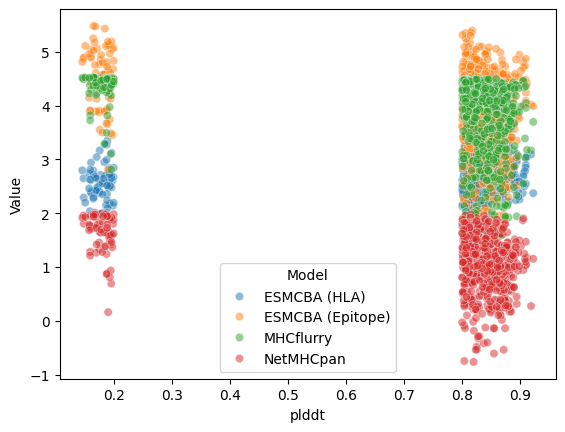

In [24]:
sns.scatterplot(data=add_plot_df, x='plddt', y='Value', hue='Model', alpha=0.5)

<Axes: xlabel='i_ptm', ylabel='Value'>

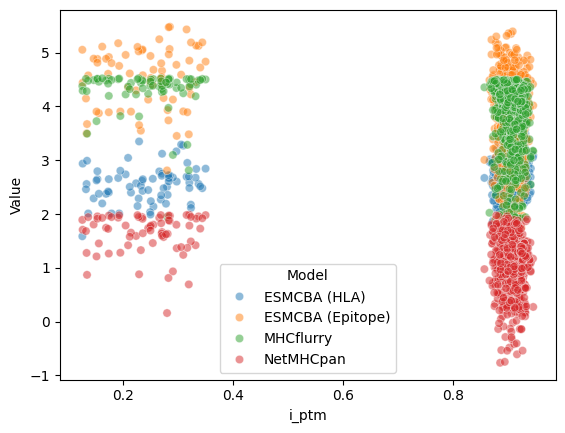

In [25]:
sns.scatterplot(data=add_plot_df, x='i_ptm', y='Value', hue='Model', alpha=0.5)

<Axes: xlabel='mpnn', ylabel='Value'>

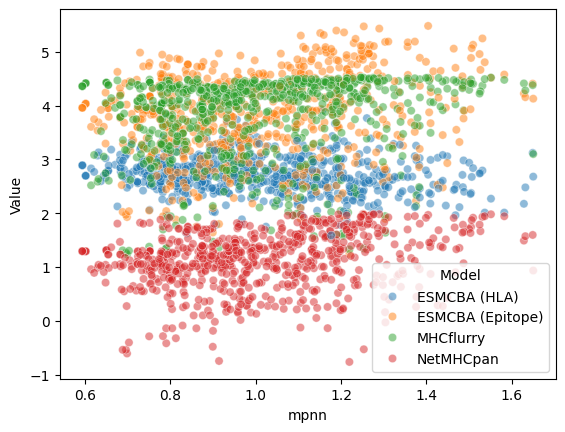

In [26]:
sns.scatterplot(data=add_plot_df, x='mpnn', y='Value', hue='Model', alpha=0.5)

<Axes: xlabel='i_pae', ylabel='Value'>

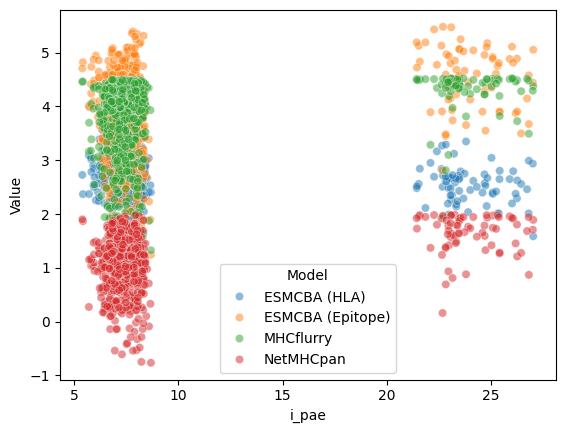

In [27]:
sns.scatterplot(data=add_plot_df, x='i_pae', y='Value', hue='Model', alpha=0.5)

<Axes: xlabel='mpnn', ylabel='Value'>

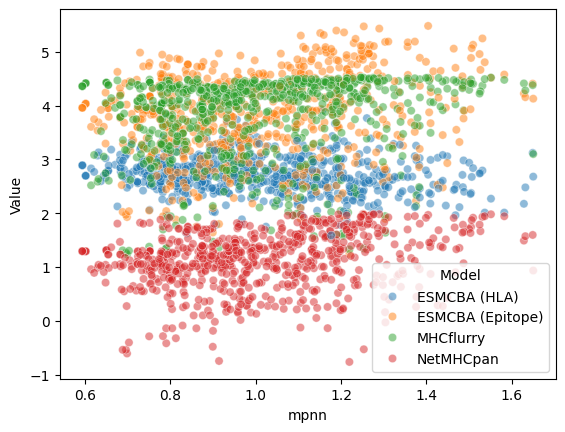

In [28]:
sns.scatterplot(data=add_plot_df, x='mpnn', y='Value', hue='Model', alpha=0.5)

<Axes: xlabel='plddt', ylabel='Value'>

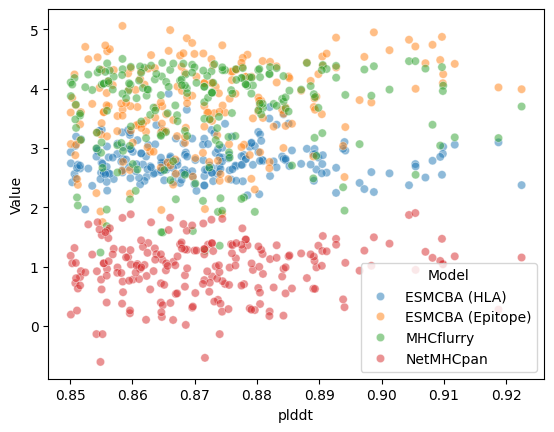

In [29]:
add_plot_df[add_plot_df['plddt'] > 0.8]
sns.scatterplot(data=add_plot_df[add_plot_df['plddt'] > 0.85], x='plddt', y='Value', hue='Model', alpha=0.5)

<Axes: xlabel='plddt', ylabel='Value'>

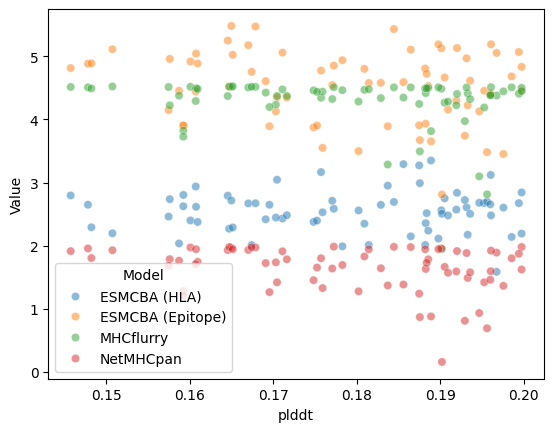

In [30]:
add_plot_df[add_plot_df['plddt'] < 0.1]
sns.scatterplot(data=add_plot_df[add_plot_df['plddt'] < 0.2], x='plddt', y='Value', hue='Model', alpha=0.5)

Median predicted values and p-values by Model and Binders:


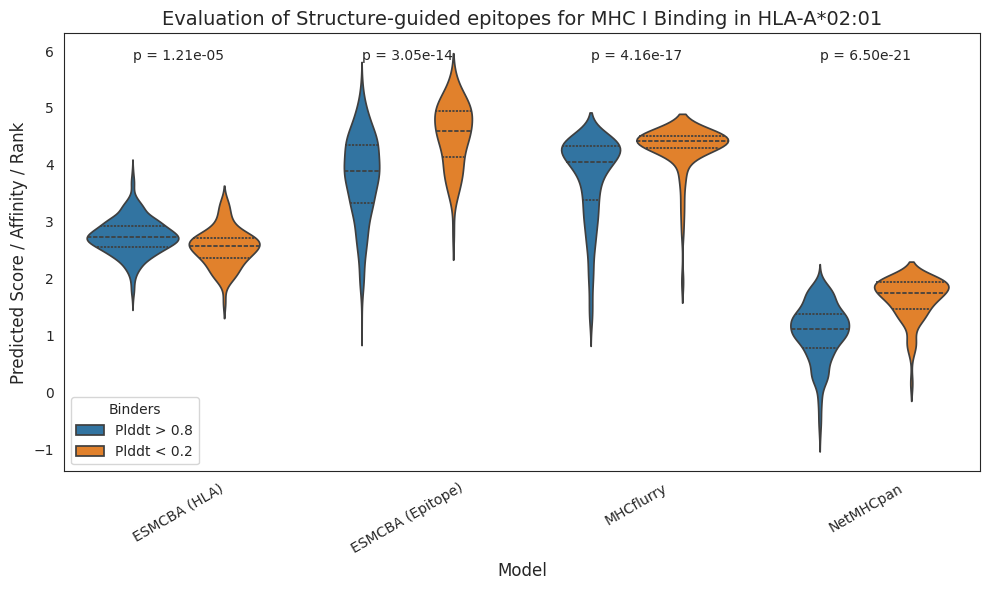

In [31]:
from scipy.stats import mannwhitneyu

median_table = (
    df_long_plot
    .groupby(["Model", "Binders"])["Value"]
    .median()
    .reset_index(name="median_Value")
)

# 2) Compute p-values per Model (high vs low confidence)
pvals = []
for model in df_long_plot["Model"].unique():
    dfm = df_long_plot[df_long_plot["Model"] == model]
    grp_high = dfm[dfm["Binders"] == "Plddt > 0.8"]["Value"]
    grp_low  = dfm[dfm["Binders"] != "Plddt > 0.8"]["Value"]  # adjust label if needed
    if len(grp_high) > 0 and len(grp_low) > 0:
        stat, p = mannwhitneyu(grp_high, grp_low, alternative="two-sided")
    else:
        p = float("nan")
    pvals.append({"Model": model, "p_value": p})

pvals_df = pd.DataFrame(pvals)

# Merge p-values into median table
median_with_p = median_table.merge(pvals_df, on="Model")
print("Median predicted values and p-values by Model and Binders:")
# print(median_with_p )

# 3) Violin plot with p-value annotations
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(
    x="Model", y="Value",
    data=df_long_plot,
    ax=ax,
    hue="Binders",
    inner="quartile"
)

# Annotate p-values
models = df_long_plot["Model"].unique()
y_max = df_long_plot["Value"].max()
y_min = df_long_plot["Value"].min()
y_range = y_max - y_min

for i, model in enumerate(models):
    p = pvals_df.loc[pvals_df["Model"] == model, "p_value"].iloc[0]
    p = p * 4 
    ax.text(
        i, 
        y_max + 0.05 * y_range, 
        f"p = {p:.2e}", 
        ha="center", 
        va="bottom", 
        fontsize=10
    )

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Predicted Score / Affinity / Rank", fontsize=12)
ax.set_title("Evaluation of Structure-guided epitopes for MHC I Binding in HLA-A*02:01", fontsize=14)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [32]:
df_merged = pd.merge(df_merged_combined, results, left_on='sequence', right_on='epitope', how='left')

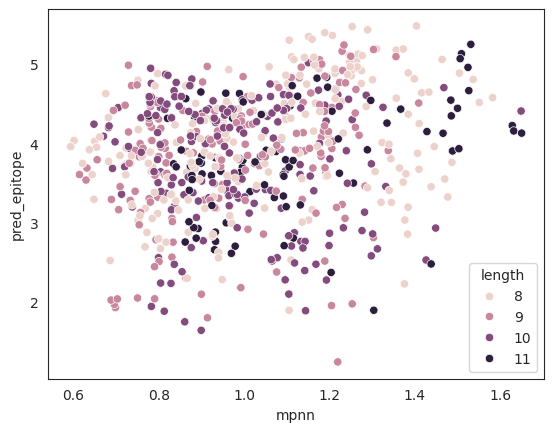

In [33]:
sns.scatterplot(data = df_merged, x = 'mpnn', y = 'pred_epitope', hue = 'length')
# sns.scatterplot(data = df_merged, x = 'mpnn', y = 'mhcflurry_affinity')
plt.show()

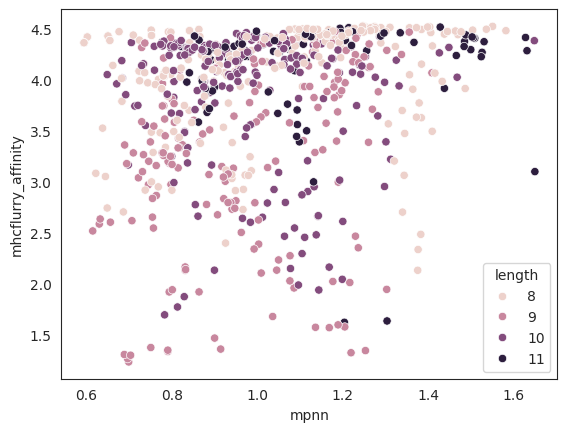

In [34]:
sns.scatterplot(data = df_merged, x = 'mpnn', y = 'mhcflurry_affinity', hue = 'length')
plt.show()

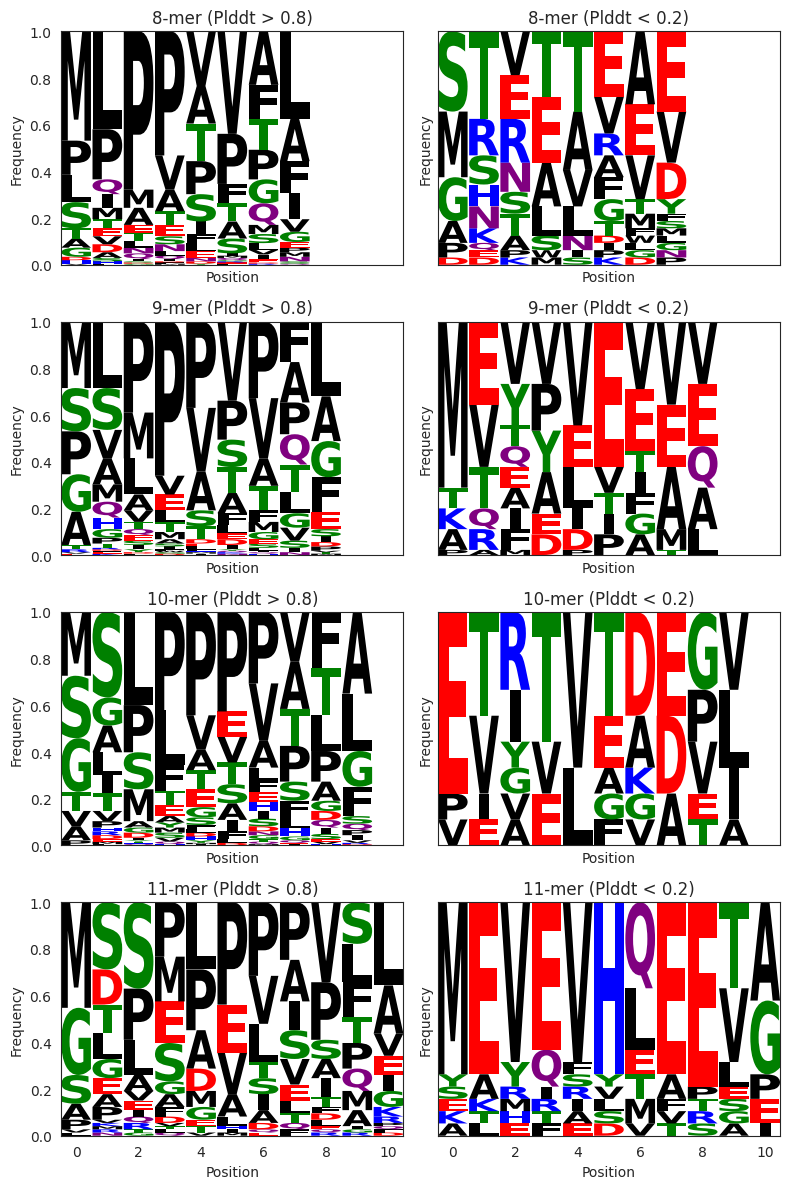

In [35]:

# 3) Sequence logos for high- vs low-confidence epitopes
# Assuming df_sequences contains sequences and Binders category includes '< 0.2'
# Here, simulate both groups for demonstration:
df_sequences = df_long_plot.copy()
df_sequences.loc[df_sequences.index[-1], 'Binders'] = 'Plddt < 0.2'  # simulate a low-confidence

lengths = [8, 9, 10, 11]
binders = df_sequences['Binders'].unique()

# 3) Create a grid of logos: rows = lengths, cols = binders
fig, axes = plt.subplots(len(lengths), len(binders),
                         figsize=(4*len(binders), 3*len(lengths)),
                         sharex=True, sharey=True)

for i, length in enumerate(lengths):
    for j, binder in enumerate(binders):
        ax = axes[i, j]
        # Filter for the exact length and binder type
        seqs = df_sequences[
            (df_sequences['Binders'] == binder) &
            (df_sequences['sequence'].str.len() == length)
        ]['sequence'].tolist()

        if not seqs:
            ax.axis('off')
            continue

        # Build counts & convert to frequency
        counts = logomaker.alignment_to_matrix(seqs, to_type='counts')
        freq = counts.div(counts.sum(axis=1), axis=0)

        # Plot logo
        logo = logomaker.Logo(freq, ax=ax, color_scheme='chemistry') 
        ax.set_title(f"{length}-mer ({binder})")
        ax.set_xlabel("Position")
        ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [36]:
# print(df_long_plot['sequence'].unique()) xs

In [37]:
import os
import requests

# List of PDB IDs
pdb_ids = """
1HSB,1SYV,1YDP,1ZVS,3HG1,3KPN,3KPO,3KYN,3KYO,3O4L,3OX8,3OXR,3OXS,3TO2,3VFM,3VFN,3VFO,
3VFP,3VFR,3VFS,3VFT,3VFU,3VFV,3VFW,4GKN,4HX1,4JRX,4JRY,4PRA,4PRB,4PRD,4PRE,4PRH,4PRI,
4PRP,5DEG,5NQ1,5NQ3,5VVP,5VWD,5VWF,6BXQ,6GGM,6GH1,6GH4,6GL1,6ID4,6IEX,6J2E,6K7T,6MTL,
6O4Y,6O4Z,6O51,6O53,6P2S,6P64,6TDO,6TDP,6TDQ,6TDR,6TDS,6TMO,6TRN,6TRO,6UJO,6UJQ,6UK2,
6UK4,6UZM,6UZN,6UZO,6UZP,6UZQ,6UZS,6V2O,6VB0,6VB1,6VB2,6VB3,6VB4,6VB5,6VB6,6VB7,6VIU,
6VPZ,6VQ2,6VQD,6VQE,6VQO,6VQY,6VQZ,6VR1,6VR5,6VRM,6VRN,6W51,6XQA,6Y26,6Y28,6Y2A,6Z9V,
6Z9W,6Z9X,7BBG,7CIQ,7CIR,7CIS,7DUU,7DYN,7DZM,7DZN,7EDO,7EJL,7EJM,7EJN,7EU2,7F4W,7JYU,
7JYV,7JYW,7JYX,7K80,7K81,7KGO,7KGP,7KGQ,7KGR,7KGS,7KGT,7LG2,7LG3,7MJ6,7MJ7,7MJ8,7MJ9,
7MKB,7N6D,7N6E,7NMD,7NME,7NMF,7NMG,7OW3,7OW4,7OW5,7OW6,7P3D,7P3E,7PB2,7PBC,7PBE,7PDW,
7Q98,7Q99,7Q9A,7Q9B,7QPJ,7R7V,7R7W,7R7X,7R7Y,7R80,7RE7,7SA2,7SIF,7SIG,7SIH,7SU9,7T0L,
7T5M,7WKJ,7WT3,7WT4,7WT5,7WZZ,7X00,7XF3,7YG3,7ZUC,8CX4,8E13,8E8I,8EC5,8EK5,8EMF,8EMG,
8EMI,8EMJ,8EMK,8EN8,8ENH,8EO8,8ES8,8ES9,8FJA,8FJB,8GOM,8GON,8GVB,8GVG,8GVI,8HN4,8ISN,
8RJ5,8RJH,8RJI,8RNG,8RNH,8ROO,8ROP,8RYN,8RYQ,8SBK,8SBL,8T6M,8V4Z,8WUL,8YIV,8YZR,8YZW,
8YZZ,8Z06,8Z07,8Z08,8ZV9,9BL5,9BL6,9BL9,9BLA,9C96,9GV6,9GV7,9L47,9L48,9L49,9L4A
""".replace("\n", "").split(",")

# Output directory
output_dir = "/clusterfs/nilah/sergio/RFdifussion/structures/pdb_files"
os.makedirs(output_dir, exist_ok=True)

# Download loop
for pdb_id in pdb_ids:
    pdb_id = pdb_id.strip().lower()
    output_file = os.path.join(output_dir, f"{pdb_id}.pdb")
    
    if os.path.exists(output_file):
        print(f"⏭️  Skipping {pdb_id.upper()} (already exists)")
        continue

    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    response = requests.get(url)
    if response.status_code == 200:
        with open(output_file, "w") as f:
            f.write(response.text)
        print(f"✅ Downloaded {pdb_id.upper()}")
    else:
        print(f"❌ Failed to download {pdb_id.upper()}")

print("🏁 Finished downloading all PDBs.")


⏭️  Skipping 1HSB (already exists)
⏭️  Skipping 1SYV (already exists)
⏭️  Skipping 1YDP (already exists)
⏭️  Skipping 1ZVS (already exists)
⏭️  Skipping 3HG1 (already exists)
⏭️  Skipping 3KPN (already exists)
⏭️  Skipping 3KPO (already exists)
⏭️  Skipping 3KYN (already exists)
⏭️  Skipping 3KYO (already exists)
⏭️  Skipping 3O4L (already exists)
⏭️  Skipping 3OX8 (already exists)
⏭️  Skipping 3OXR (already exists)
⏭️  Skipping 3OXS (already exists)
⏭️  Skipping 3TO2 (already exists)
⏭️  Skipping 3VFM (already exists)
⏭️  Skipping 3VFN (already exists)
⏭️  Skipping 3VFO (already exists)
⏭️  Skipping 3VFP (already exists)
⏭️  Skipping 3VFR (already exists)
⏭️  Skipping 3VFS (already exists)
⏭️  Skipping 3VFT (already exists)
⏭️  Skipping 3VFU (already exists)
⏭️  Skipping 3VFV (already exists)
⏭️  Skipping 3VFW (already exists)
⏭️  Skipping 4GKN (already exists)
⏭️  Skipping 4HX1 (already exists)
⏭️  Skipping 4JRX (already exists)
⏭️  Skipping 4JRY (already exists)
⏭️  Skipping 4PRA (a

In [38]:
import os
import requests
import pandas as pd

# Prepare list for metadata
meta_list = []

for pdb in pdb_ids:
    pdb = pdb.strip().lower()
    url = f"https://data.rcsb.org/rest/v1/core/entry/{pdb}"
    try:
        r = requests.get(url)
        if r.status_code != 200:
            raise ValueError(f"Status {r.status_code}")
        data = r.json()
        
        meta = {
            "pdb_id": pdb.upper(),
            "title": data.get("struct", {}).get("title", ""),
            "method": data.get("exptl", [{}])[0].get("method", ""),
            "resolution": data.get("rcsb_entry_info", {}).get("resolution_combined", [None])[0],
            "release_date": data.get("rcsb_accession_info", {}).get("initial_release_date", ""),
            "revision_date": data.get("rcsb_accession_info", {}).get("revision_date", "")
        }
        meta_list.append(meta)
    except Exception as e:
        meta_list.append({
            "pdb_id": pdb.upper(),
            "title": None, "method": None,
            "resolution": None,
            "release_date": None,
            "revision_date": None
        })

# Build DataFrame and display
df_meta = pd.DataFrame(meta_list)
df_meta.to_csv('metadata.csv', index=False)

In [39]:
import re

df_meta_cp = df_meta.copy()

# 1. Clean up titles (no newlines)
df_meta_cp['title'] = df_meta_cp['title'].str.replace(r"[\n\r]", " ", regex=True)

df_meta_cp['title'] = df_meta_cp['title'].str.replace(':','')
# df_meta_cp['title'] = df_meta_cp['title'].str.replace('-','')
# df_meta_cp['title'] = df_meta_cp['title'].str.replace(' ','-')

# 2. Extract HLA alleles of the form HLA-A*01:01 (or B,C, etc.)
df_meta_cp['hla_allele'] = df_meta_cp['title'].str.extract(r'(HLA-[A-Z]\*\d{2}\d{2})')

# 3. Filter to rows where we actually found one
df_hla = df_meta_cp[df_meta_cp['hla_allele'].notna()][['pdb_id', 'hla_allele']]
df_hla = pd.merge(df_hla, df_meta, on='pdb_id', how='right')

In [40]:
df_meta_cp[~df_meta_cp['hla_allele'].notna()] #[['pdb_id', 'hla_allele']].to_csv('hla_alleles.csv', index=False)

,pdb_id,title,method,resolution,release_date,revision_date,hla_allele
0,1HSB,DIFFERENT LENGTH PEPTIDES BIND TO HLA-AW68 SIM...,X-RAY DIFFRACTION,1.90,1993-10-31T00:00:00+0000,2024-10-30T00:00:00+0000,NaN
2,1YDP,1.9A crystal structure of HLA-G,X-RAY DIFFRACTION,1.90,2005-03-08T00:00:00+0000,2024-10-23T00:00:00+0000,NaN
3,1ZVS,Crystal structure of the first class MHC mamu ...,X-RAY DIFFRACTION,2.80,2006-06-13T00:00:00+0000,2024-11-20T00:00:00+0000,NaN
4,3HG1,Germline-governed recognition of a cancer epit...,X-RAY DIFFRACTION,3.00,2009-07-28T00:00:00+0000,2024-11-27T00:00:00+0000,NaN
5,3KPN,Crystal Structure of HLA B*4403 in complex wit...,X-RAY DIFFRACTION,2.00,2009-12-22T00:00:00+0000,2024-10-16T00:00:00+0000,NaN
...,...,...,...,...,...,...,...
223,8Z07,The structure of HLA-A/peptide from virus,X-RAY DIFFRACTION,2.70,2025-01-29T00:00:00+0000,2025-01-29T00:00:00+0000,NaN
224,8Z08,The structure of HLA/peptide from virus,X-RAY DIFFRACTION,2.01,2025-01-29T00:00:00+0000,2025-01-29T00:00:00+0000,NaN
225,8ZV9,Complex structure of HLA2402 with recognizing ...,X-RAY DIFFRACTION,2.60,2024-08-21T00:00:00+0000,2024-11-13T00:00:00+0000,NaN
231,9GV6,Structure of TCR in complex with peptide-HLA,X-RAY DIFFRACTION,2.77,2025-04-23T00:00:00+0000,2025-04-23T00:00:00+0000,NaN


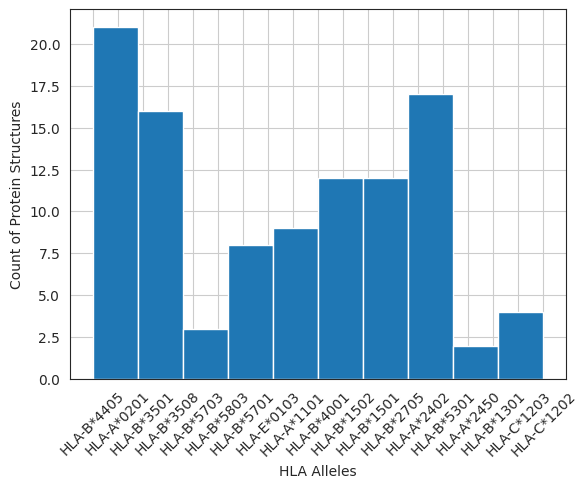

In [41]:
df_hla['hla_allele'].hist()
plt.xticks(rotation=45)
# plt.title('HLA Alleles')
plt.xlabel('HLA Alleles')
plt.ylabel('Count of Protein Structures')
plt.show()

In [42]:
# from Bio.PDB import PDBParser, is_aa
# import pandas as pd
# import os

# # Local directory containing the PDBs
# pdb_dir = "/clusterfs/nilah/sergio/RFdifussion/structures/pdb_files"

# # Get list of all PDB files
# pdb_files = [f for f in os.listdir(pdb_dir) if f.endswith(".pdb")]

# parser = PDBParser(QUIET=True)
# results = []

# for pdb_file in pdb_files:
#     pdb_id = pdb_file.replace(".pdb", "").upper()
#     path = os.path.join(pdb_dir, pdb_file)

#     try:
#         structure = parser.get_structure(pdb_id, path)[0]  # Use first model
#     except Exception as e:
#         print(f"❌ Skipping {pdb_id} due to error: {e}")
#         continue

#     for chain in structure.get_chains():
#         residues = [res for res in chain if is_aa(res)]
#         results.append({
#             "pdb_id": pdb_id,
#             "chain_id": chain.id,
#             "num_residues": len(residues),
#             "residues_preview": "-".join(res.resname for res in residues[:5]) + ("..." if len(residues) > 5 else "")
#         })

# df = pd.DataFrame(results)
# df.to_csv("pdb_chain_summary.csv", index=False)
# print("✅ Finished. Saved chain info to pdb_chain_summary.csv")


In [43]:
pdb_chain_summary = pd.read_csv("pdb_chain_summary.csv")

In [44]:
# from Bio.PDB import PDBParser, NeighborSearch
# from scipy.spatial.distance import cdist
# import numpy as np
# import pandas as pd
# import os

# pdb_dir = "/clusterfs/nilah/sergio/RFdifussion/structures/pdb_files"
# cutoff = 5.0  # Å

# parser = PDBParser(QUIET=True)
# all_contacts = []

# for pdb_file in os.listdir(pdb_dir):
#     if not pdb_file.endswith(".pdb"):
#         continue

#     pdb_id = pdb_file.replace(".pdb", "").upper()
#     pdb_path = os.path.join(pdb_dir, pdb_file)

#     try:
#         structure = parser.get_structure(pdb_id, pdb_path)[0]  # first model
#         chains = list(structure.get_chains())

#         # Chain lengths for auto-classification
#         chain_lens = {ch.id: len([res for res in ch if res.id[0] == " "]) for ch in chains}
#         epitopes = [cid for cid, l in chain_lens.items() if 7 <= l <= 15]
#         mhcs     = [cid for cid, l in chain_lens.items() if 150 <= l <= 300]

#         for epi_id in epitopes:
#             for mhc_id in mhcs:
#                 atoms_epi = [a for a in structure[epi_id].get_atoms() if a.element != "H"]
#                 atoms_mhc = [a for a in structure[mhc_id].get_atoms() if a.element != "H"]
#                 ns = NeighborSearch(atoms_epi + atoms_mhc)

#                 for atom in atoms_epi:
#                     for neighbor in ns.search(atom.coord, cutoff):
#                         if neighbor in atoms_mhc:
#                             res_epi = atom.get_parent()
#                             res_mhc = neighbor.get_parent()
#                             coords_epi = np.array([a.coord for a in res_epi if a.element != "H"])
#                             coords_mhc = np.array([a.coord for a in res_mhc if a.element != "H"])
#                             min_dist = cdist(coords_epi, coords_mhc).min()

#                             all_contacts.append({
#                                 "pdb_id": pdb_id,
#                                 "epitope_chain": epi_id,
#                                 "epitope_resnum": res_epi.id[1],
#                                 "epitope_resname": res_epi.resname,
#                                 "mhc_chain": mhc_id,
#                                 "mhc_resnum": res_mhc.id[1],
#                                 "mhc_resname": res_mhc.resname,
#                                 "min_distance": round(min_dist, 2)
#                             })

#     except Exception as e:
#         print(f"❌ {pdb_id} skipped: {e}")
#         continue

# # Create and save the final dataframe
# df = pd.DataFrame(all_contacts)
# df.to_csv("mhc_epitope_contacts.csv", index=False)
# print("✅ Saved contact table as mhc_epitope_contacts.csv")


In [45]:
mhc_epitope_contacts = pd.read_csv("mhc_epitope_contacts.csv")

In [46]:

interactions = mhc_epitope_contacts.drop_duplicates().reset_index(drop=True)

In [47]:
# 1. Count how many distinct epitope residues contact each MHC residue
contact_counts = interactions.groupby(['mhc_chain', 'mhc_resnum'])['epitope_resnum'].nunique().reset_index()
contact_counts = contact_counts.rename(columns={'epitope_resnum': 'contact_count'})

# 2. Merge back into original interaction DataFrame
interactions = interactions.merge(contact_counts, on=['mhc_chain', 'mhc_resnum'], how='left')

# 3. Assign importance tier based on contact count
interactions["importance"] = interactions["contact_count"].map(
    lambda x: "core_hotspot" if x >= 4 else
              "high_contact" if x == 3 else
              "medium_contact" if x == 2 else
              "low_contact"
)


In [48]:
interactions_sub = interactions[(interactions['mhc_resnum'] < 400) & (interactions['epitope_resnum'] < 14)]

In [49]:
interactions_sub['pdb_id'].nunique()

221

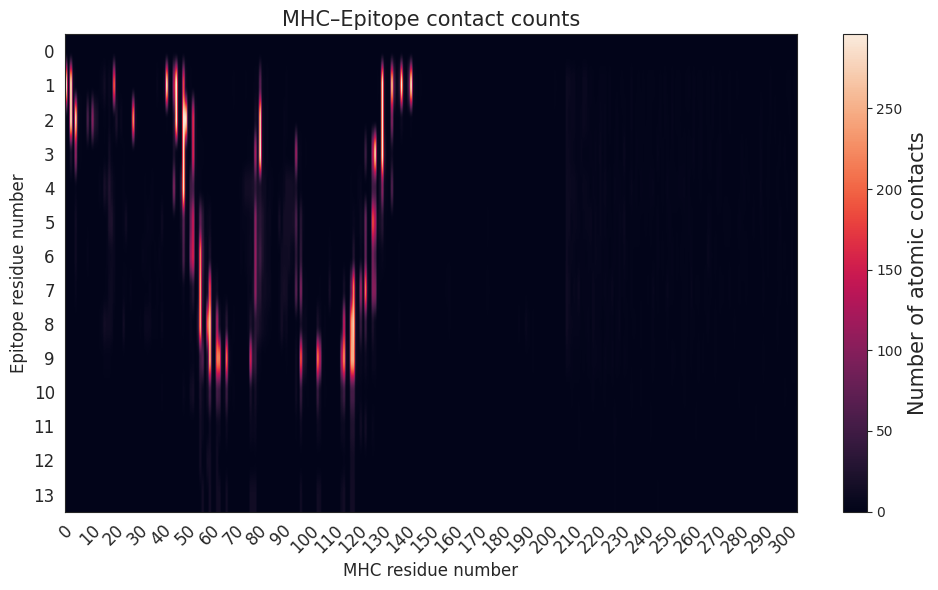

In [50]:
interactions_sub
contact_matrix = (
    pd.crosstab(interactions_sub["mhc_resnum"], interactions_sub["epitope_resnum"])
    .sort_index(axis=0)  # sort MHC residues
    .sort_index(axis=1)  # sort epitope residues
).T

# 2. Plot heatmap
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(contact_matrix, aspect="auto")

# Axis labels & ticks
ax.set_ylabel("Epitope residue number", size = 12)
ax.set_xlabel("MHC residue number", size = 12)
ax.set_title("MHC–Epitope contact counts", size = 15)

# Tick positions & labels
ax.set_xticks(np.arange(0, 310, 10))
ax.set_xticklabels(np.arange(0, 310, 10), size = 12, rotation =45)
ax.set_yticks(range(contact_matrix.shape[0]))
ax.set_yticklabels(contact_matrix.index, size = 12)

# Colorbar to indicate count intensity
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of atomic contacts", size = 15) #, rotation = 0)

plt.tight_layout()

In [51]:
np.arange(0, 389, 10)

array([  0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120,
       130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250,
       260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380])

In [52]:
core_counts = (
    interactions[(interactions['importance'] == 'core_hotspot') & 
                 (interactions['min_distance'] < 3)]
    .groupby('pdb_id')['mhc_resnum']
    .nunique()
    .reset_index(name='n_core_hotspot_residues')
    .sort_values(by='n_core_hotspot_residues', ascending=False)
)


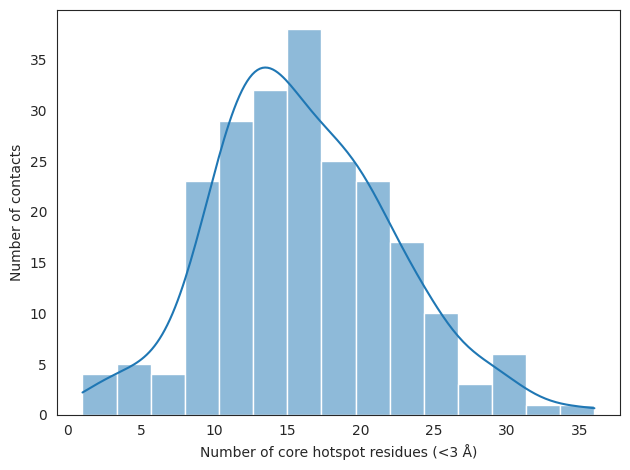

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(core_counts['n_core_hotspot_residues'], bins=15, kde=True)
plt.xlabel('Number of core hotspot residues (<3 Å)')
plt.ylabel('Number of contacts')
# plt.title('Distribution of Strong Core Hotspot Contacts')
plt.tight_layout()
plt.show()


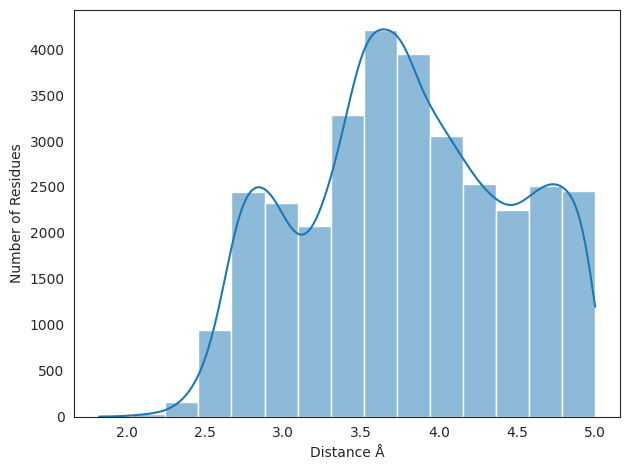

In [54]:
sns.histplot(interactions['min_distance'], bins=15, kde=True)
plt.xlabel('Distance Å')
plt.ylabel('Number of Residues')
# plt.title('Distribution of Å distance per Contacts')
plt.tight_layout()
plt.show()


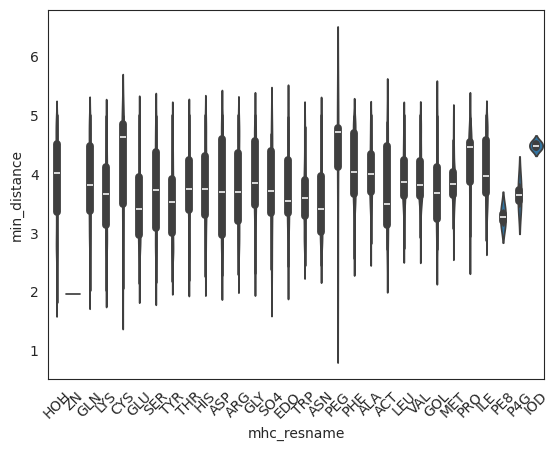

In [55]:
sns.violinplot(data=interactions.sort_values(by='min_distance'), x='mhc_resname', y='min_distance')
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='pdb_id', ylabel='min_distance'>

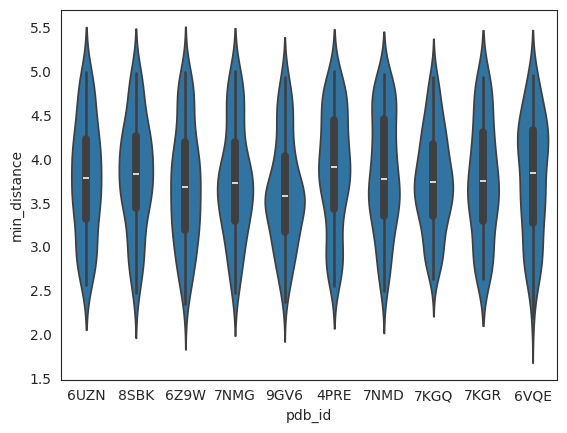

In [56]:
#find the distribution of min distance per pdb_id
interactions.groupby('pdb_id')['min_distance'].describe().reset_index()

#plot the distribution of min distance per pdb_id one bar per pdb_id 
#Plot a violin plot of the distribution of min distance per pdb_id
# sns.violinplot(data=interactions, x='pdb_id', y='min_distance')

#there are too many pdb_ids to plot all of them, so we will plot only the first 10
sns.violinplot(data=interactions[interactions['pdb_id'].isin(interactions['pdb_id'].unique()[:10])], x='pdb_id', y='min_distance')

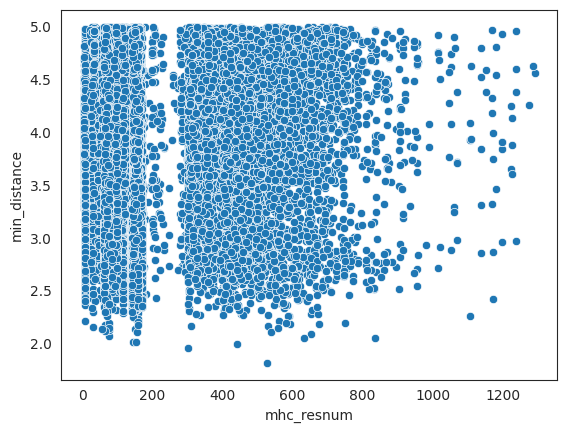

In [57]:
sns.scatterplot(data=interactions, x='mhc_resnum', y='min_distance')
plt.show()

<Axes: xlabel='mpnn', ylabel='i_ptm'>

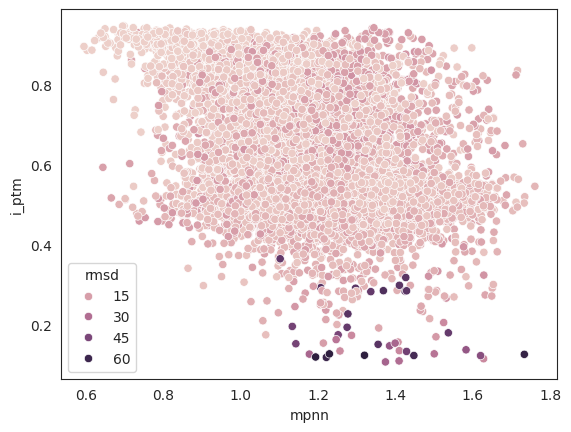

In [58]:
sns.scatterplot(data=results, x = 'mpnn', y='i_ptm', hue = 'rmsd')

In [59]:
results.head()

,design,n,mpnn,plddt,i_ptm,i_pae,rmsd,seq,RUN,epitope,length
0,0,0,1.578673,0.371702,0.538972,16.794023,6.563395,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/7RTD,AALDEFLPP,9
1,0,1,1.734082,0.300439,0.519114,17.692208,6.457840,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/7RTD,DALAVYLPP,9
2,0,2,1.592548,0.300626,0.489816,18.015840,5.452526,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/7RTD,AALEEFTPP,9
3,0,3,1.649663,0.378298,0.551428,16.531989,7.321498,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/7RTD,SLLDVFLPP,9
4,0,4,1.552341,0.304425,0.503693,17.588620,5.115226,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/7RTD,DALDTFTPP,9


<Axes: xlabel='mpnn', ylabel='i_ptm'>

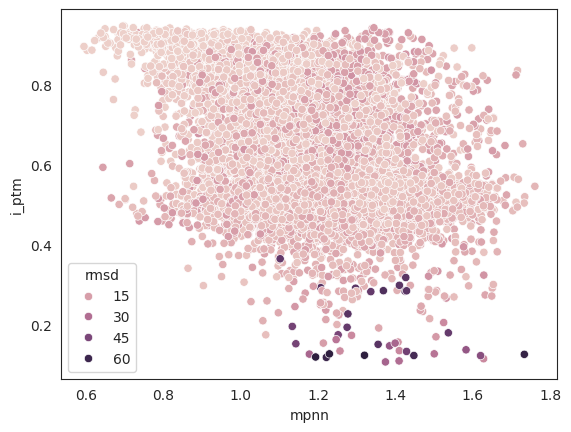

In [60]:
sns.scatterplot(data=results, x = 'mpnn', y='i_ptm', hue = 'rmsd')

<Axes: xlabel='rmsd', ylabel='i_ptm'>

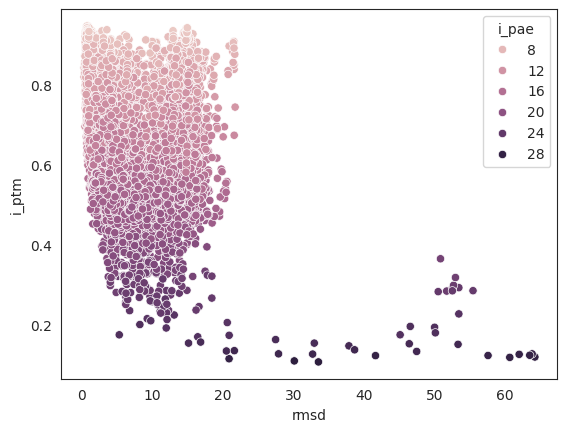

In [61]:
sns.scatterplot(data=results, x = 'rmsd', y='i_ptm', hue = 'i_pae')

<Axes: xlabel='plddt', ylabel='i_ptm'>

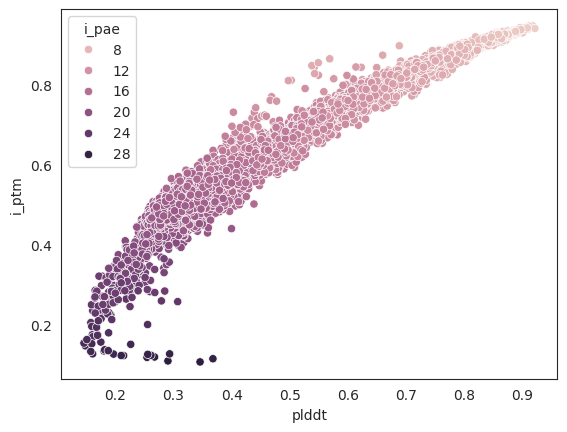

In [62]:
sns.scatterplot(data=results, x = 'plddt', y='i_ptm', hue = 'i_pae')

In [63]:
# Count chains per PDB
chain_counts = pdb_chain_summary.groupby('pdb_id').size().reset_index(name='num_chains')

# Filter to PDBs that have exactly 3 chains
three_chain_pdbs = chain_counts[chain_counts['num_chains'] == 3].sort_values(by='num_chains', ascending=False)


In [64]:
# Filter the full chain summary to only 3-chain PDBs
filtered_summary = pdb_chain_summary[pdb_chain_summary['pdb_id'].isin(three_chain_pdbs['pdb_id'])]

In [65]:
# import os
# from pathlib import Path
# import pandas as pd

# # --------------------------------------------------------------------------------------------------
# # ASSUMPTION: 'filtered_summary' and 'interactions' DataFrames are already in your workspace.
# # - filtered_summary columns: ['pdb_id', 'chain_id', 'num_residues', 'residues_preview']
# # - interactions columns: ['pdb_id','epitope_chain','mhc_chain','mhc_resnum','importance',...]
# # --------------------------------------------------------------------------------------------------

# # 1) Build the job parameters DataFrame
# job_params = []

# # Only include PDBs with exactly 3 chains
# chain_counts = filtered_summary.groupby('pdb_id').size()
# three_chain_pdbs = chain_counts[chain_counts == 3].index.tolist()

# for pdb_id in three_chain_pdbs:
#     chains_df = filtered_summary[filtered_summary['pdb_id'] == pdb_id]
#     chains = ",".join(chains_df['chain_id'].tolist())
    
#     # Determine epitope chain: the one with smallest num_residues
#     ep_chain = chains_df.loc[chains_df['num_residues'].idxmin(), 'chain_id']
    
#     # Collect hotspot residues (core + high + medium)
#     inter_df = interactions[
#         (interactions['pdb_id'] == pdb_id) &
#         (interactions['epitope_chain'] == ep_chain) &
#         (interactions['importance'].isin(['core_hotspot','high_contact','medium_contact']))
#     ]
#     hotspots = sorted({f"{row['mhc_chain']}{row['mhc_resnum']}" for _, row in inter_df.iterrows()})

#     if len(hotspots) < 5:
#         inter_df = interactions[
#             (interactions['pdb_id'] == pdb_id) &
#             (interactions['epitope_chain'] == ep_chain) &
#             (interactions['importance'].isin(['high_contact','medium_contact']))
#         ]
    
#     job_params.append({
#         'pdb_id': pdb_id,
#         'chains': chains,
#         'epitope_chain': ep_chain,
#         'hotspots': ",".join(hotspots)
#     })

# df_job_params = pd.DataFrame(job_params)

# # 2) Generate SLURM scripts from df_job_params
# script_path = "/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/run_RFDiffusionMHC_epitope.py"
# sh_dir   = Path("/clusterfs/nilah/sergio/RFdifussion/slurm_jobs/EPITOPE_SERIES2")
# log_dir  = Path("/clusterfs/nilah/sergio/RFdifussion/logs/EPITOPE_SERIES2")
# sh_dir.mkdir(parents=True, exist_ok=True)
# log_dir.mkdir(parents=True, exist_ok=True)

# iterations_list = [50]
# num_seqs_list   = [32]

# for trial in range(1000, 1100):
#     for _, row in df_job_params.iterrows():
#         # get chain lengths for contigs construction
#         lengths = {
#             ch: filtered_summary.query(f"pdb_id=='{row.pdb_id}' & chain_id=='{ch}'").num_residues.item()
#             for ch in row.chains.split(",")
#         }
#         # build contigs string
#         parts = []
#         for ch, L in lengths.items():

#             if ch == row.epitope_chain:
                
#                 LENGTH = np.random.randint(7,13)
#                 L = LENGTH

#                 parts.append(f"0/{L}")
#             else:
#                 parts.append(f"{ch}1-{L}/0")
#         full_contigs = " ".join(parts)

#         for it in iterations_list:
#             for ns in num_seqs_list:
#                 base = f"{row.pdb_id}_C{row.epitope_chain}{lengths[row.epitope_chain]}_I{it}_NS{ns}_{LENGTH}_{trial}"
#                 fname = f"RFD_{base}"
#                 sh_path = sh_dir / f"{fname}.sh"
#                 cmd = (
#                     f"python {script_path} "
#                     f"--name {fname} "
#                     f"--pdb {row.pdb_id} "
#                     f"--contigs \"{full_contigs}\" "
#                     f"--hotspots \"{row.hotspots}\" "
#                     f"--chains {row.chains} "
#                     f"--epitope_chain {row.epitope_chain} "
#                     f"--iterations {it} "
#                     f"--num_seqs {ns}"
#                 )
#                 with open(sh_path, "w") as fh:
#                     fh.write("#!/bin/bash\n")
#                     fh.write("#SBATCH --account=co_nilah\n")
#                     fh.write("#SBATCH --partition=savio3_gpu\n")
#                     fh.write("#SBATCH --qos=savio_lowprio\n")
#                     fh.write("#SBATCH --cpus-per-task=4\n")
#                     fh.write("#SBATCH --mem=16G\n")
#                     fh.write("#SBATCH --gres=gpu:1\n")
#                     fh.write("#SBATCH --time=00:57:00\n")
#                     fh.write(f"#SBATCH --job-name={fname}\n")
#                     fh.write(f"#SBATCH --output={log_dir}/{fname}_%j.out\n")
#                     fh.write(f"#SBATCH --error={log_dir}/{fname}_%j.err\n\n")
#                     fh.write("source /clusterfs/nilah/sergio/miniconda3/etc/profile.d/conda.sh\n")
#                     fh.write("conda activate SE3nv\n\n")
#                     fh.write(cmd + "\n")
#                 os.chmod(sh_path, 0o755)
#                 print(f"✅ Created {sh_path.name}")

### Expading to new structures

In [66]:
results_file = glob.glob('/clusterfs/nilah/sergio/RFdifussion/outputs/*/*/*.csv')

def aggregate_results(results_files, run_id_level=-2, extra_columns=None):
    """
    Aggregate CSV files into a single DataFrame with run identifiers.
    
    Args:
        results_files (list): List of paths to CSV files.
        run_id_level (int): Directory level to extract run ID (e.g., -2 for parent of filename).
        extra_columns (dict): Optional dictionary of column_name: lambda_function to add metadata.
    
    Returns:
        pd.DataFrame: Concatenated DataFrame with run IDs and optional columns.
    """
    if not results_files:
        print("Warning: No files provided.")
        return pd.DataFrame()

    dfs = []
    for file_path in results_files:
        # try:
        # Read CSV
        tmp = pd.read_csv(file_path)
        
        # Extract run ID from path
        # run_id = os.path.split(os.path.dirname(file_path))[run_id_level]
        tmp['RUN'] = file_path.split('/')[7]
        tmp['PDB'] = file_path.split('/')[6]
        # Add optional columns
        # if extra_columns:
        #     for col_name, func in extra_columns.items():
        #         tmp[col_name] = func(file_path)
        
        dfs.append(tmp)
        # print(f"Processed: {file_path}")

    # Concatenate all DataFrames
    if dfs:
        results = pd.concat(dfs, axis=0 )# , ignore_index=True)
        print(f"Aggregated {len(dfs)} files into DataFrame with {len(results)} rows.")
        return results
    else:
        print("No valid files processed.")
        return pd.DataFrame()

results_pdbs = aggregate_results(results_file, run_id_level=-2) #, extra_columns=extra_columns)
#Aggregated 1225 files into DataFrame with 39200 rows.
# Aggregated 1386 files into DataFrame with 44352 rows.
# Aggregated 1425 files into DataFrame with 45600 rows.
# Aggregated 1529 files into DataFrame with 48928 rows.
# Aggregated 1723 files into DataFrame with 55136 rows.
# Aggregated 1773 files into DataFrame with 56736 rows.

Aggregated 1773 files into DataFrame with 56736 rows.


In [67]:
results_meta = pd.merge(results_pdbs, df_meta, left_on='PDB', right_on='pdb_id', how='left')

results_meta['title'] = results_meta['title'].str.replace(r"[\n\r]", " ", regex=True)

results_meta['title'] = results_meta['title'].str.replace(':','')
# results_meta['title'] = results_meta['title'].str.replace('-','')
# results_meta['title'] = results_meta['title'].str.replace(' ','-')

# 2. Extract HLA alleles of the form HLA-A*01:01 (or B,C, etc.)
results_meta['hla_allele'] = results_meta['title'].str.extract(r'(HLA-[A-Z]\*\d{2}\d{2})')

In [78]:
results_meta['epitope'] = results_meta['seq'].apply(lambda x: x.split("/")[1])
results_meta['length'] = results_meta['epitope'].apply(lambda x: len(x))

In [70]:
results_meta[['PDB', 'length','hla_allele','RUN']].drop_duplicates('RUN').groupby(['PDB','hla_allele'])['RUN'].size().reset_index().sort_values(by='RUN', ascending=False).head(15)

,PDB,hla_allele,RUN
13,6UZN,HLA-B*1502,24
20,6VB1,HLA-B*1502,22
24,6VB5,HLA-B*1502,22
17,6UZS,HLA-B*1501,21
8,5VWF,HLA-B*5803,21
44,7MJ9,HLA-A*0201,21
30,6VQD,HLA-B*2705,20
56,9L48,HLA-C*1202,20
33,7EJM,HLA-A*2402,20
12,6UZM,HLA-B*1502,20


In [71]:
results_meta[['PDB', 'length','hla_allele']].drop_duplicates().groupby(['PDB','hla_allele'])['length'].size().reset_index(name='length_sizes').sort_values('length_sizes', ascending=False).head(15)

,PDB,hla_allele,length_sizes
17,6UZS,HLA-B*1501,6
13,6UZN,HLA-B*1502,5
25,6VB6,HLA-B*1502,5
19,6VB0,HLA-B*1502,5
23,6VB4,HLA-B*1502,5
22,6VB3,HLA-B*1501,5
24,6VB5,HLA-B*1502,5
32,7EJL,HLA-A*2402,5
30,6VQD,HLA-B*2705,5
27,6VIU,HLA-B*1502,5


In [72]:
results_meta[results_meta['hla_allele'] == 'HLA-B*1502']['PDB'].unique()


array(['6VB6', '6VIU', '6VB7', '6UZM', '6UZO', '6VB1', '6UZN', '6VB0',
       '6VB4', '6VB2', '6VB5'], dtype=object)

In [73]:
results_meta = pd.merge(results_pdbs, df_meta, left_on='PDB', right_on='pdb_id', how='left')

In [74]:
results_meta[results_meta['PDB'] == '6VB4']['title'].values[0]

'HLA-B*15:02 complexed with a synthetic peptide'

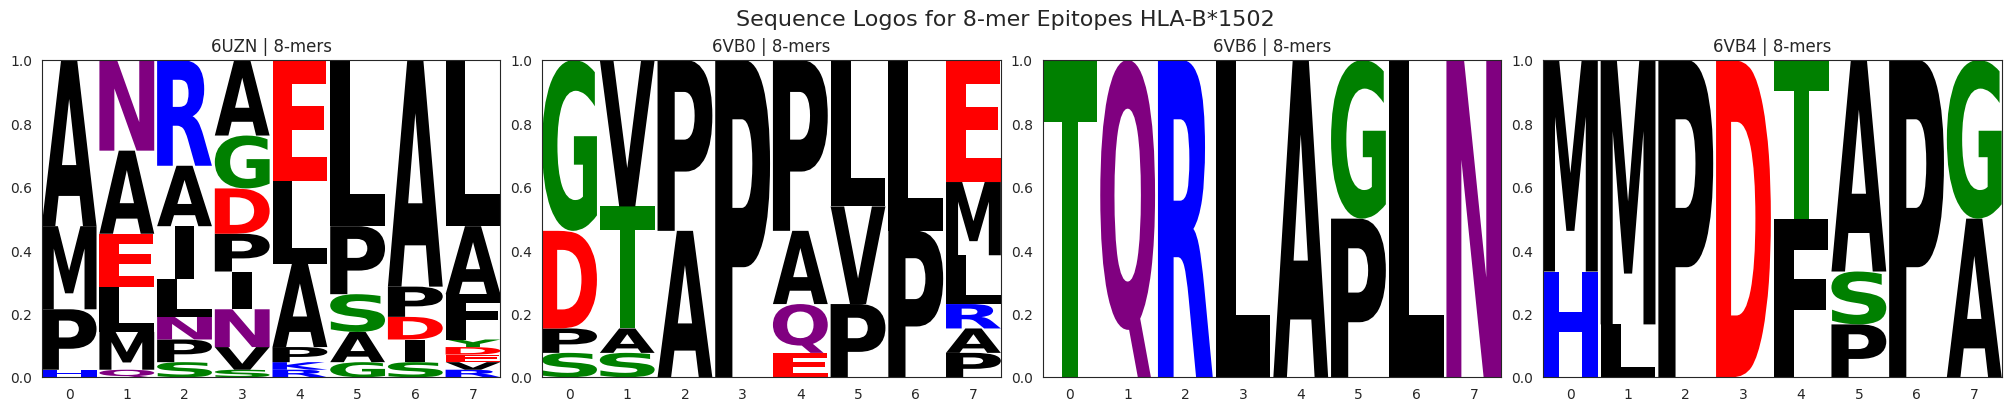

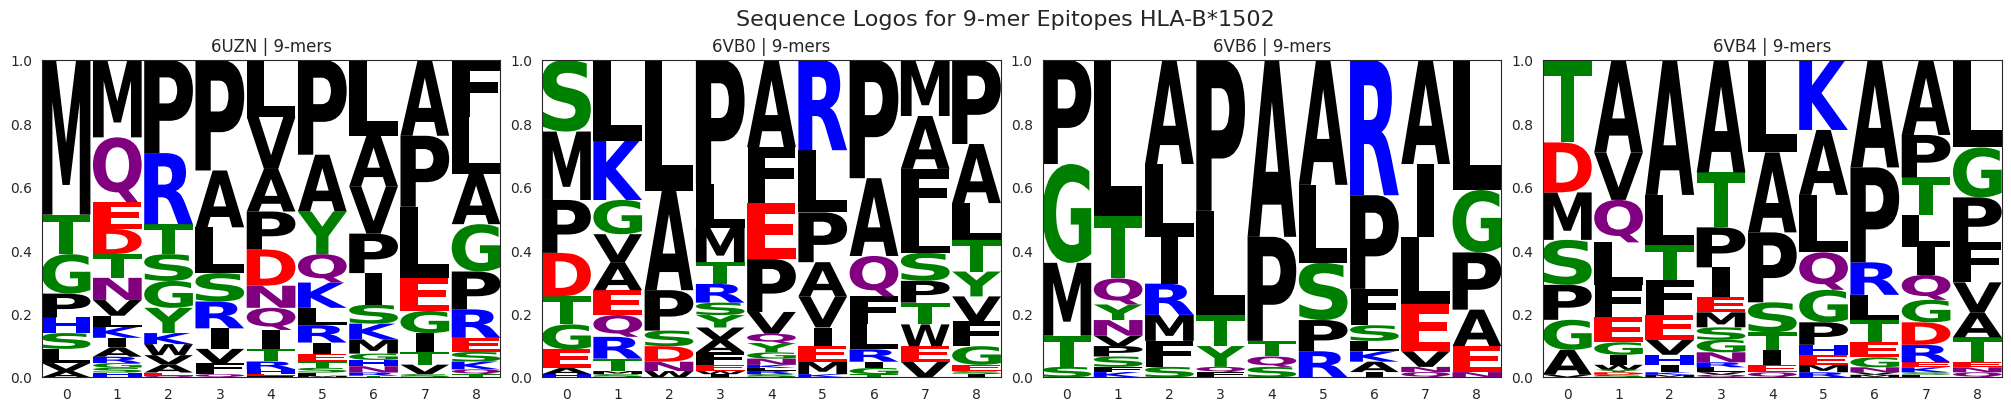

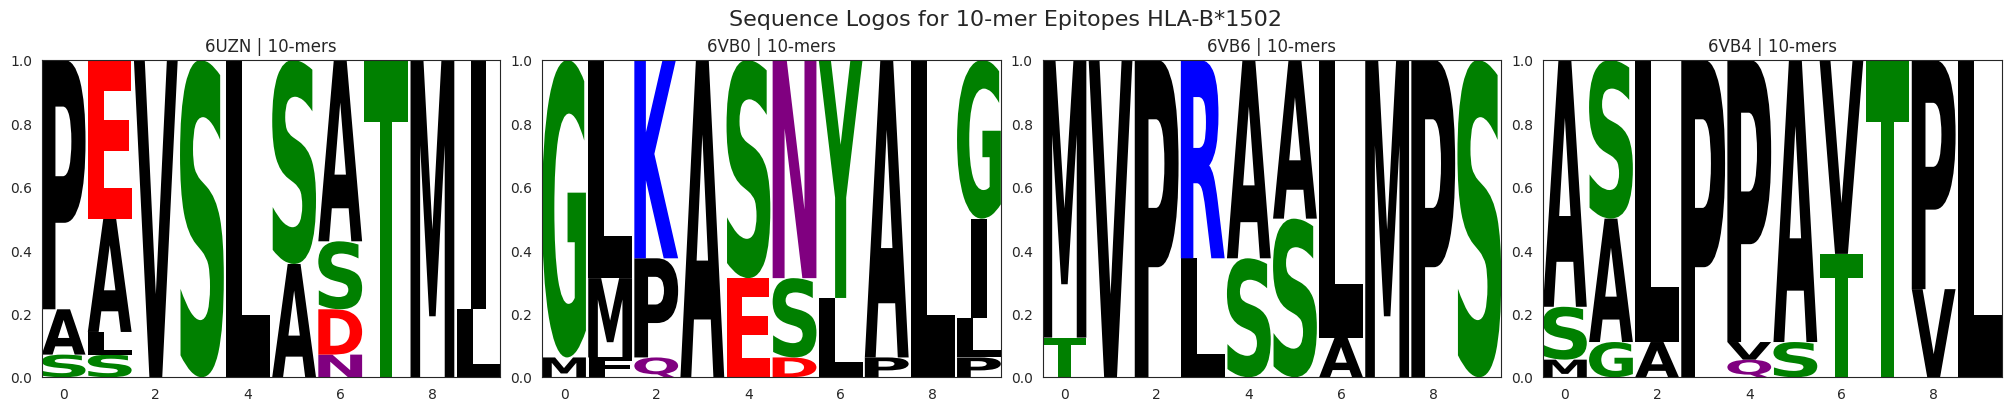

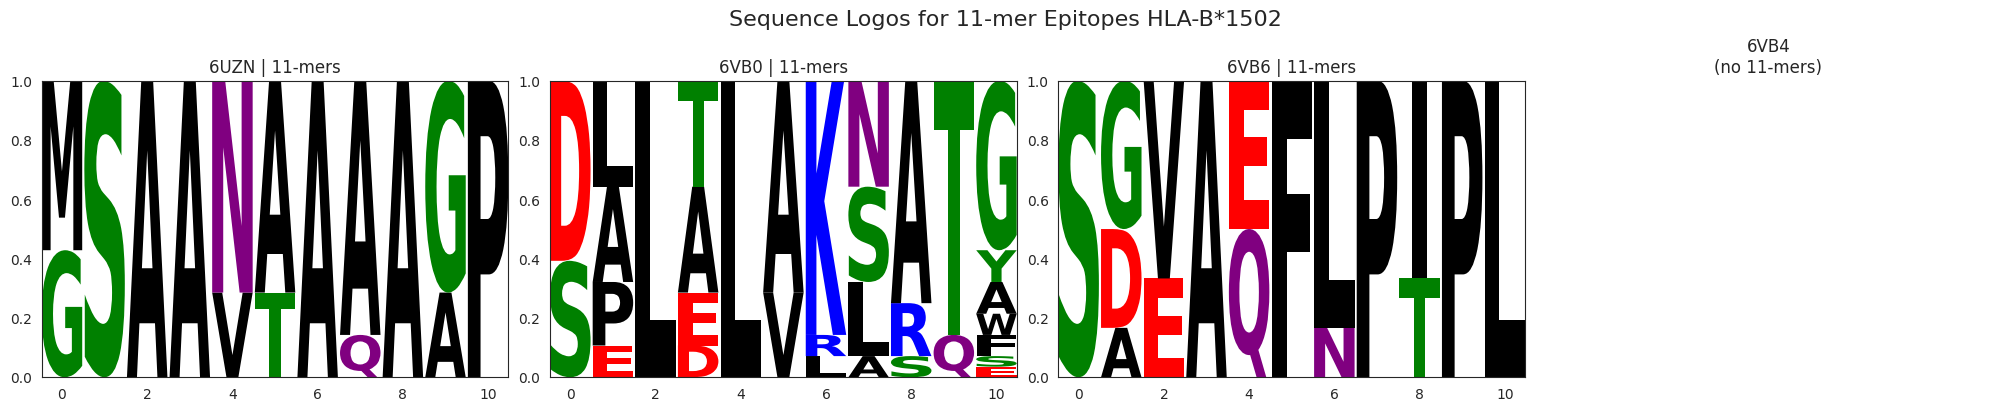

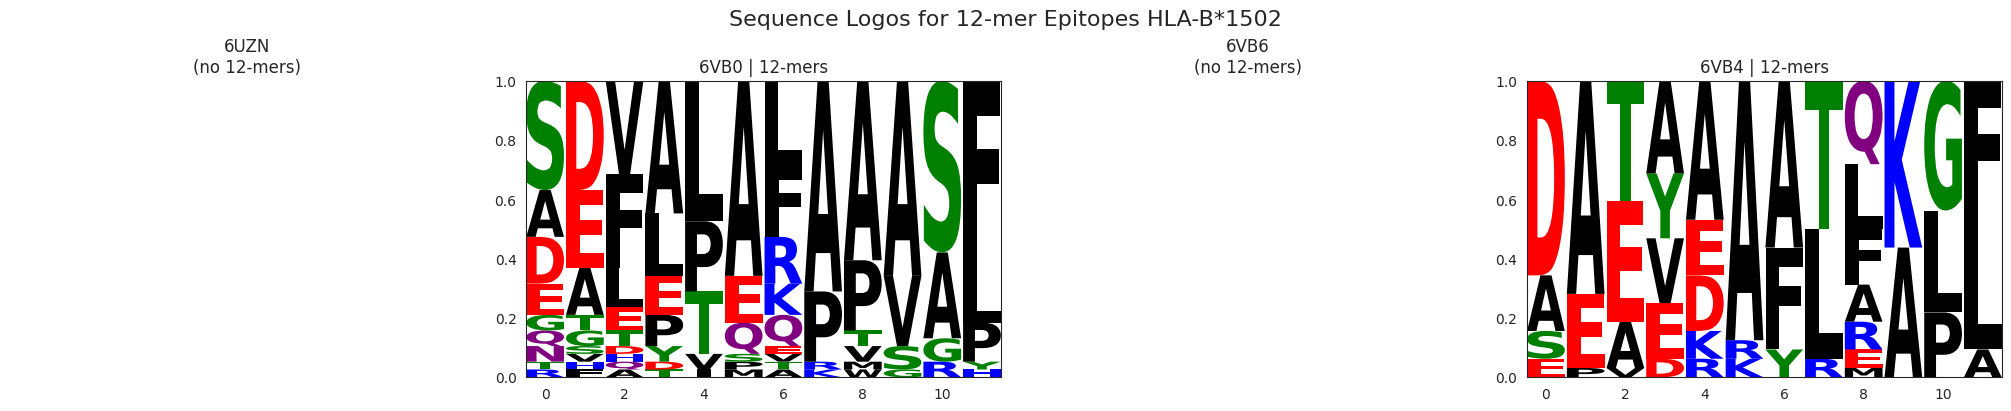

In [79]:
pdbs = ['6UZN', '6VB0', '6VB6', '6VB4']
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

# Loop through epitope lengths
for n in range(8, 15):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), constrained_layout=True)
    found_any = False

    for i, pdb in enumerate(pdbs):
        ax = axes[i]
        results_pdb = results_meta[results_meta['PDB'] == pdb].drop_duplicates('seq')
        sequences = results_pdb[(results_pdb['epitope'].str.len() == n) & (results_pdb['plddt'] > 0.3) ]['epitope'].tolist() #& (results_pdb['plddt'] > 0.8)

        if len(sequences) == 0:
            ax.axis('off')
            ax.set_title(f"{pdb}\n(no {n}-mers)")
            continue

        found_any = True
        freq_matrix = np.zeros((n, len(amino_acids)))

        for seq in sequences:
            for j, aa in enumerate(seq):
                if aa in amino_acids:
                    freq_matrix[j, amino_acids.index(aa)] += 1

        freq_matrix /= len(sequences)
        freq_df = pd.DataFrame(freq_matrix, columns=amino_acids)

        logomaker.Logo(freq_df, ax=ax, color_scheme='chemistry')
        ax.set_title(f"{pdb} | {n}-mers")
        ax.set_ylabel("")

    if found_any:
        fig.suptitle(f"Sequence Logos for {n}-mer Epitopes HLA-B*1502", fontsize=16)
        plt.show()
    else:
        plt.close(fig)
